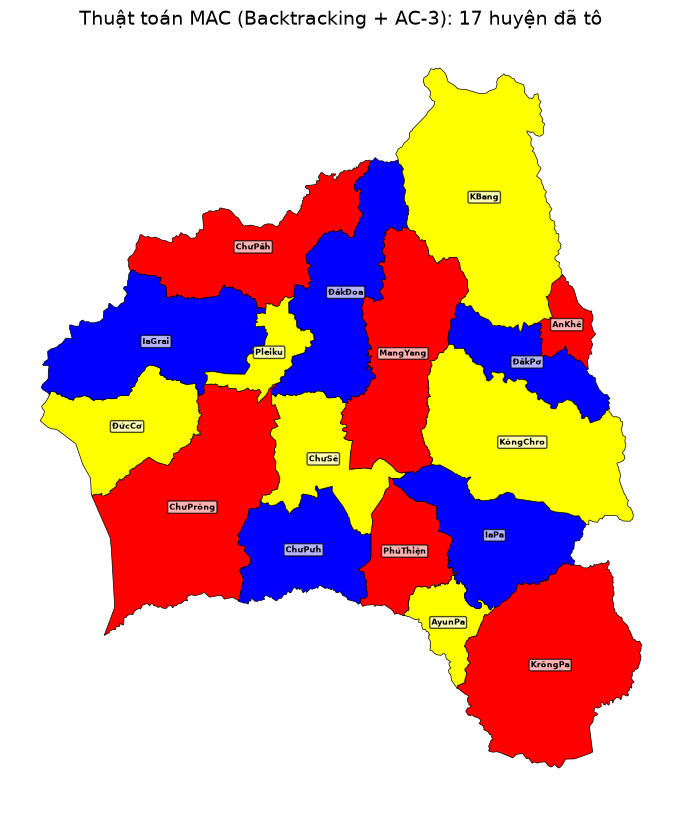

Tô màu thành công bằng thuật toán MAC!


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import copy

# LOAD DỮ LIỆU
gdf = gpd.read_file("D:/Dai_Hoc/HK4_dot2/Tri Tue Nhan Tao/ToBanDo/gia_lai_districts.json")
gia_lai_map = gdf[gdf['NAME_1'] == 'GiaLai'].copy()
if gia_lai_map.crs is None: gia_lai_map.set_crs(epsg=4326, inplace=True)
gia_lai_map = gia_lai_map.to_crs(epsg=3857)

# Xây dựng danh sách kề
adj_list = {}
for i, row in gia_lai_map.iterrows():
    neighbors = gia_lai_map[gia_lai_map.geometry.distance(row.geometry) < 0.001]['NAME_2'].tolist()
    adj_list[row['NAME_2']] = [n for n in neighbors if n != row['NAME_2']]

# CÁC HÀM HỖ TRỢ (AC-3 và Vẽ)
def ac3_inference(domains, adj_list):
    queue = [(xi, xj) for xi in adj_list for xj in adj_list[xi]]
    while queue:
        xi, xj = queue.pop(0)
        # Loại bỏ các giá trị không thỏa mãn ràng buộc
        new_domain = [x for x in domains[xi] if any(x != y for y in domains[xj])]
        if len(new_domain) < len(domains[xi]):
            domains[xi] = new_domain
            if not domains[xi]: return None # Không thể tô màu
            for xk in adj_list[xi]:
                if xk != xj: queue.append((xk, xi))
    return domains

def draw_step(step_assignment):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    current_colors = gia_lai_map['NAME_2'].map(step_assignment).fillna('lightgrey')
    gia_lai_map.plot(ax=ax, color=current_colors, edgecolor='black', linewidth=0.5)
    for idx, row in gia_lai_map.iterrows():
        centroid = row['geometry'].centroid
        plt.annotate(text=row['NAME_2'], xy=(centroid.x, centroid.y), ha='center', va='center', fontsize=6, fontweight='bold', bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
    plt.title(f"Thuật toán MAC (Backtracking + AC-3): {len(step_assignment)} huyện đã tô", fontsize=14)
    plt.axis('off'); plt.show(); time.sleep(0.1)

# BACKTRACKING VỚI INFREENCE (AC-3)
assignment = {}
all_colors = ['red', 'blue', 'yellow', 'green']
domains = {district: list(all_colors) for district in gia_lai_map['NAME_2']}

def backtrack(current_domains):
    if len(assignment) == len(gia_lai_map): return True
    
    # Heuristic MRV
    unassigned = [d for d in gia_lai_map['NAME_2'] if d not in assignment]
    district = min(unassigned, key=lambda d: len(current_domains[d]))
    
    for color in list(current_domains[district]):
        new_assignment = assignment.copy()
        new_assignment[district] = color
        
        # Inference: Chạy AC-3 sau mỗi lần gán
        next_domains = copy.deepcopy(current_domains)
        next_domains[district] = [color]
        next_domains = ac3_inference(next_domains, adj_list)
        
        if next_domains is not None:
            assignment[district] = color
            draw_step(assignment)
            if backtrack(next_domains): return True
            del assignment[district]
            
    return False

# CHẠY CHƯƠNG TRÌNH
draw_step({})
if backtrack(domains):
    print("Tô màu thành công bằng thuật toán MAC!")
else:
    print("Không tìm được lời giải!")